# **IRIS FLOWER CLASSIFICATION MODEL(RANDOM FOREST)**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score)
from sklearn.preprocessing import StandardScaler
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('iris.csv')
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
98,5.1,2.5,3.0,1.1,versicolor
119,6.0,2.2,5.0,1.5,virginica
94,5.6,2.7,4.2,1.3,versicolor
29,4.7,3.2,1.6,0.2,setosa
53,5.5,2.3,4.0,1.3,versicolor
113,5.7,2.5,5.0,2.0,virginica
48,5.3,3.7,1.5,0.2,setosa
73,6.1,2.8,4.7,1.2,versicolor
124,6.7,3.3,5.7,2.1,virginica
139,6.9,3.1,5.4,2.1,virginica


In [3]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [4]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
142,5.8,2.7,5.1,1.9,virginica


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df[df.duplicated()]

,sepal_length,sepal_width,petal_length,petal_width,species


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.9 KB


In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df['species'].value_counts()

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

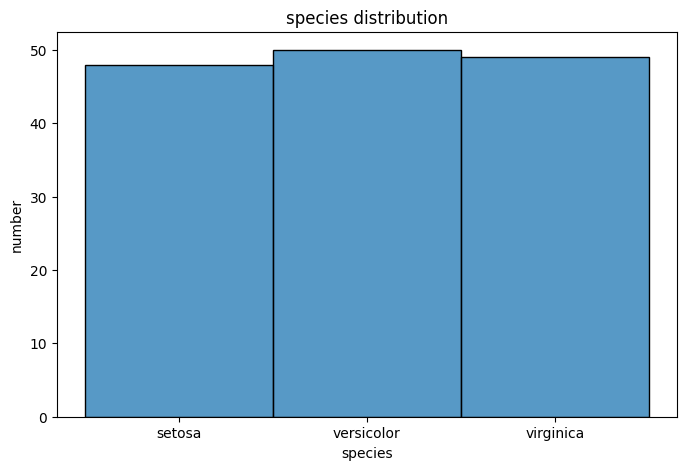

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='species',bins=15)
plt.title('species distribution')
plt.xlabel('species')
plt.ylabel('number')
plt.show()

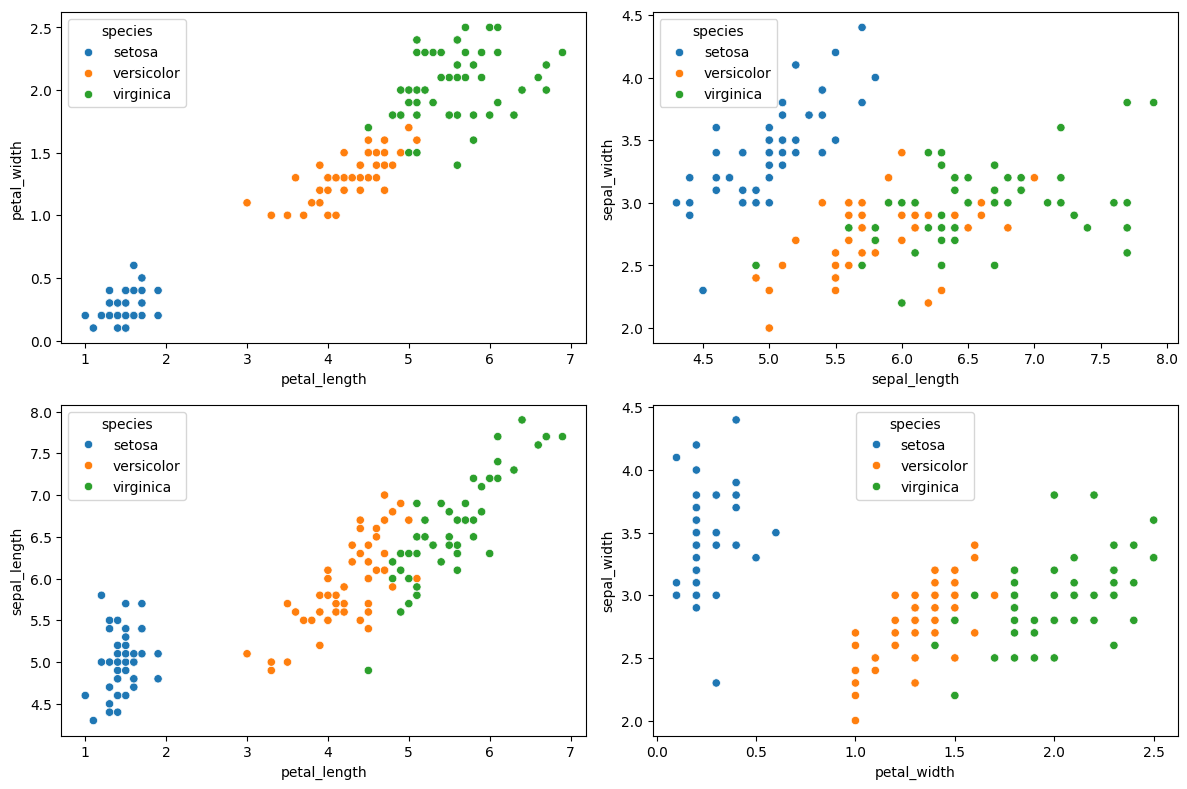

In [11]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.scatterplot(x='petal_length', y='petal_width',data=df,hue='species')

plt.subplot(2,2,2)
sns.scatterplot(x='sepal_length', y='sepal_width', data=df,hue='species')

plt.subplot(2,2,3)
sns.scatterplot(x='petal_length', y='sepal_length', data=df,hue='species')

plt.subplot(2,2,4)
sns.scatterplot(x='petal_width', y='sepal_width', data=df,hue='species')

plt.tight_layout()
plt.show()

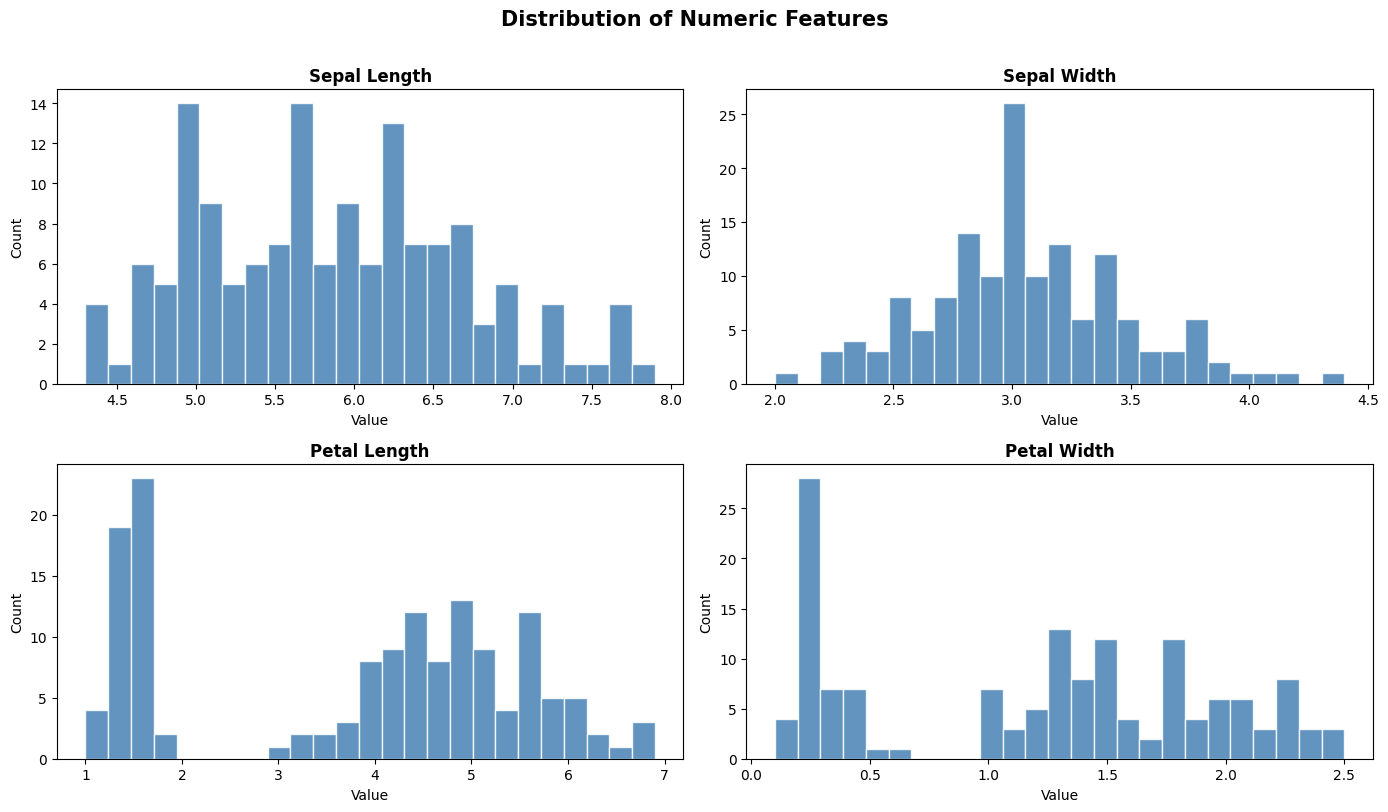

In [12]:
numeric_cols = ['sepal_length'	,'sepal_width',	'petal_length'	,'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Numeric Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

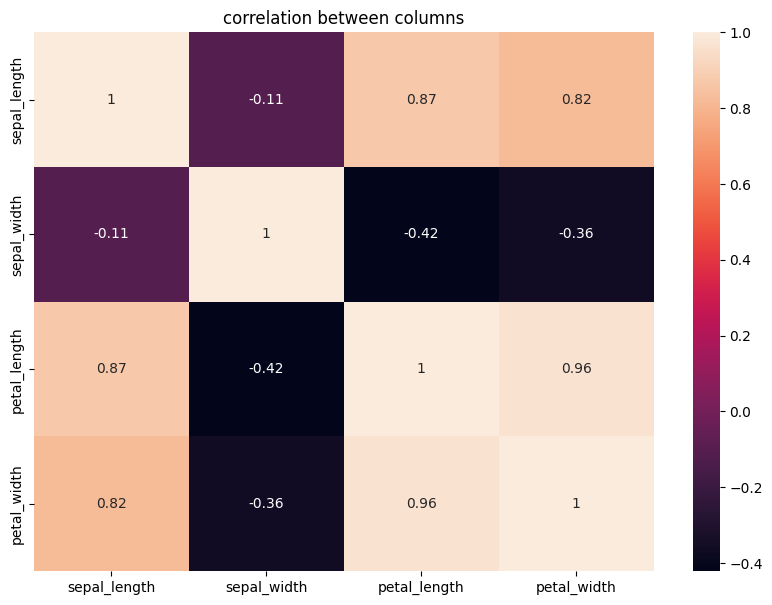

In [13]:
plt.figure(figsize=(10,7))
corr=df[df.select_dtypes(include='number').columns].corr()
sns.heatmap(corr,annot=True)
plt.title('correlation between columns')
plt.show()

In [14]:
X=df.drop(columns='species')
y=df['species']

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    random_state=42,
    oob_score=True 
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_pred=model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred)*100)
print("OOB Score:", model.oob_score_)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy 93.33333333333333
OOB Score: 0.9572649572649573
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.90      0.90      0.90        10
   virginica       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

[[11  0  0]
 [ 0  9  1]
 [ 0  1  8]]


In [19]:
feature_scores = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)
feature_scores

petal_length    0.478000
petal_width     0.383956
sepal_length    0.107516
sepal_width     0.030529
dtype: float64

In [20]:
model_df=pd.DataFrame({'Actual':y_test.values,
             'Predicted':y_pred})
print(model_df.sample(10))

        Actual   Predicted
0    virginica   virginica
9       setosa      setosa
18   virginica   virginica
21   virginica   virginica
5       setosa      setosa
23   virginica   virginica
4    virginica  versicolor
29      setosa      setosa
6   versicolor  versicolor
12   virginica   virginica


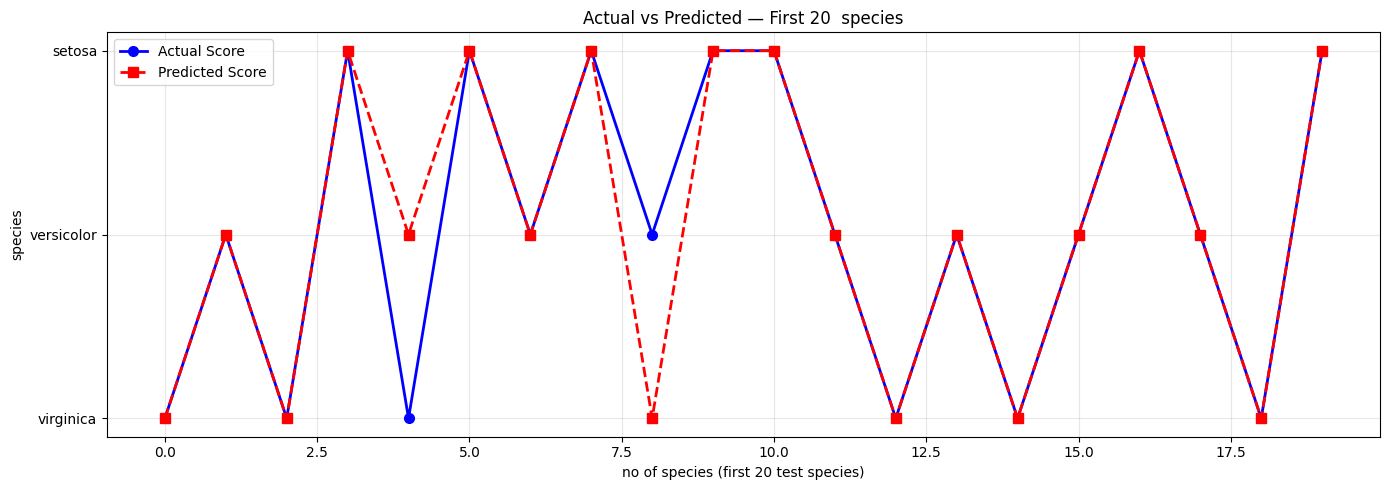

In [21]:
plt.figure(figsize=(14, 5))
x_pos = range(20)

# Blue solid line = actual scores
plt.plot(x_pos, y_test.values[:20], 'bo-', label='Actual Score', linewidth=2, markersize=7)

# Red dashed line = what the model predicted
plt.plot(x_pos, y_pred[:20], 'rs--', label='Predicted Score', linewidth=2, markersize=7)

plt.xlabel('no of species (first 20 test species)')
plt.ylabel('species')
plt.title('Actual vs Predicted — First 20  species')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import joblib
save_data = {
    'model'  : model,
    'scaler' : scaler,
    'columns': list(X.columns)
}
joblib.dump(save_data, 'iris_model.joblib')

['iris_model.joblib']